# Controlled Neural–DTB Game Experiments (2D, 3D, and 5D)

This notebook provides three independent, editable experiments. It compares Neural–DTB with direct Euler–Maruyama simulation of the same stochastic game dynamics.

[Open this notebook in Colab](https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex/game-dynamics-dtb/DTB_Game_Ver1/notebooks/controlled_game_experiments_colab.ipynb)

**Important:** the `RUN_2D`, `RUN_3D`, and `RUN_5D` switches default to `False`. Configure and inspect each block first, then enable and run one experiment at a time. The 3D and 5D defaults use 2,000 particles and depth-4 networks and may take several minutes.

## Block 0 — Colab instructions and repository setup

1. In Colab, choose **Runtime → Change runtime type → T4 GPU** when available.
2. Run Blocks 0 and 1 once.
3. In each experiment, edit the form-style arguments and run its configuration cell.
4. Confirm the printed dimension, equilibria, neural architecture, tangent size, and SVD tolerance.
5. Set that experiment's `RUN_*` switch to `True` and run its computation cell.
6. Run the following results cell to display snapshots, diagnostics, and metrics.
7. Run one 2,000-particle experiment at a time to limit memory usage.

Re-running an enabled computation cell overwrites only that experiment's output folder.

In [1]:
# BLOCK 0A — Clone the requested GitHub branch and install its requirements.
import os
import pathlib
import shutil
import subprocess
import sys

REPO_URL = 'https://github.com/sun-mengwei/dtb-colab-experiments.git'
BRANCH = 'codex/game-dynamics-dtb'
REPO_DIR = pathlib.Path('/content/dtb-colab-experiments')
PROJECT_DIR = REPO_DIR / 'DTB_Game_Ver1'

if not REPO_DIR.exists():
    subprocess.run(
        ['git', 'clone', '--branch', BRANCH, '--single-branch', REPO_URL, str(REPO_DIR)],
        check=True,
    )
else:
    print(f'Updating existing clone: {REPO_DIR}')
    subprocess.run(['git', '-C', str(REPO_DIR), 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', str(REPO_DIR), 'checkout', BRANCH], check=True)
    subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only', 'origin', BRANCH], check=True)

os.chdir(PROJECT_DIR)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
print('Project directory:', pathlib.Path.cwd())


Project directory: /content/dtb-colab-experiments/DTB_Game_Ver1


In [2]:
# BLOCK 0B — Check the runtime. No experiment is run here.
import platform
import torch

print('Python:', platform.python_version())
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Selected automatic device:', 'cuda' if torch.cuda.is_available() else 'cpu')


Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
Selected automatic device: cuda


## Block 1 — Shared experiment, equilibrium, diagnostic, and metric helpers

This block contains only reusable functions. It does not run a DTB or Euler–Maruyama experiment.

For every game, the direct baseline uses the general Euler–Maruyama step

$$X_{k+1}=X_k+h\,b(X_k)+\sigma\sqrt{h}\,\xi_k,\qquad \xi_k\sim N(0,I).$$

Neural–DTB instead projects the Fokker–Planck velocity $b-\tfrac12Dq$ into the selected neural tangent span, with $D=\sigma\sigma^\top$.

**Source-matching periodic reset.** For exactly $L$ steps, the code freezes $\theta_{\rm block}$ and one random parameter subset $S$, while accumulating $s=\sum_k\alpha_k$. It then defines $f_{\rm target}(z)=f_{\theta_{\rm block}}(z)+hJ_{\theta_{\rm block},S}(z)s$, precomputes this target on fresh $z\sim\lambda$, fits all trainable parameters with Adam plus cosine learning-rate decay, reports RMSE on another fresh reference sample, and begins a new block. This is the rule used in the original `DTB_rep/run_game_dtb.py`; there is no residual-triggered reset. Set $L=0$ to disable it.

In [3]:
# BLOCK 1A — Imports and shared constructors.
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from game_dtb.models import TangentMLP, count_trainable
from game_dtb.runner import run_experiment

OUTPUT_ROOT = Path('outputs/controlled_colab')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def build_experiment_args(
    *, game, dim, particles, width, depth, basis_size, svd_rtol,
    steps, step_size, noise_std, seed, output_dir,
    initial_distribution='uniform', run_sde_baseline=True, device='auto',
    refit_interval=50, refit_optimizer_steps=2000, refit_learning_rate=1e-3,
    refit_batch_size=2048, refit_samples=10000, refit_test_samples=4000,
):
    return SimpleNamespace(
        game=game, dim=dim, particles=particles, steps=steps, step_size=step_size,
        basis_size=basis_size, svd_rtol=svd_rtol, noise_std=noise_std,
        diffusion_entry=None, initial_distribution=initial_distribution,
        uniform_low=0.0, uniform_high=1.0, initial_mean=0.5,
        initial_std=0.15, initial_variance=0.03,
        architecture='mlp', width=width, depth=depth, activation='tanh', rank=8,
        jacobian_chunk=128, derivative_chunk=64,
        refit_interval=refit_interval, refit_optimizer_steps=refit_optimizer_steps,
        refit_learning_rate=refit_learning_rate, refit_batch_size=refit_batch_size,
        refit_samples=refit_samples, refit_test_samples=refit_test_samples,
        linear_target=0.5, linear_contraction=1.0, linear_rotation=0.35,
        cournot_b=1.0, cournot_mu=2.0,
        snapshot_times='0,0.2,0.4,0.6,0.8,1.0',
        plot_low=-0.4, plot_high=1.0, run_sde_baseline=run_sde_baseline,
        device=device, dtype='float32', seed=seed,
        print_every=max(1, steps // 5), output_dir=str(output_dir),
    )

def print_configuration(name, args, equilibria, stable_mask):
    model = TangentMLP(
        dim=args.dim, width=args.width, depth=args.depth,
        activation=args.activation, dtype=torch.float32,
    )
    labels = ['stable' if flag else 'unstable' for flag in stable_mask]
    print(f'=== {name} CONTROLLED SETUP ===')
    print(f'Game / player dimension: {args.game} / d={args.dim}')
    print(f'Particles: N={args.particles}; initial law={args.initial_distribution} on [0,1]^{args.dim}')
    print(f'Physical grid: K={args.steps}, h={args.step_size}, T={args.steps * args.step_size:g}')
    print(f'Noise amplitude: sigma={args.noise_std}; diffusion diagonal D_ii={args.noise_std ** 2:g}')
    print(f'Initial tangent NN: MLP {args.dim} -> ' + ' -> '.join([str(args.width)] * args.depth) + f' -> {args.dim}')
    print(f'Hidden depth={args.depth}; width={args.width}; activation={args.activation}')
    print(f'Trainable tangent parameters M={count_trainable(model)}')
    print(f'Selected tangent-bundle size m={args.basis_size}')
    print(f'Relative SVD tolerance={args.svd_rtol:g}')
    print(f'Source-matching reset: L={args.refit_interval} steps (0 disables); Adam steps={args.refit_optimizer_steps}')
    print(f'Reset fit: lr={args.refit_learning_rate:g}; batch={args.refit_batch_size}; train samples={args.refit_samples}; fresh-test samples={args.refit_test_samples}')
    print(f'Euler–Maruyama baseline enabled={args.run_sde_baseline}')
    print(f'Device={args.device}; seed={args.seed}; output={args.output_dir}')
    print('Known equilibria:')
    for index, (point, label) in enumerate(zip(equilibria, labels), start=1):
        print(f'  E{index}: {np.array2string(point, precision=5)} [{label}]')


In [4]:
# BLOCK 1B — Equilibrium graphs. Stable points are red circles; unstable points are gold X markers.
def plot_equilibria(equilibria, stable_mask, title):
    equilibria = np.asarray(equilibria, dtype=float)
    stable_mask = np.asarray(stable_mask, dtype=bool)
    dim = equilibria.shape[1]
    stable = equilibria[stable_mask]
    unstable = equilibria[~stable_mask]

    def scatter_groups(axis, x_index, y_index, *, three_d=False, z_index=None):
        if stable.size:
            if three_d:
                axis.scatter(stable[:, x_index], stable[:, y_index], stable[:, z_index],
                             s=70, color='#d62728', marker='o', label='stable')
            else:
                axis.scatter(stable[:, x_index], stable[:, y_index],
                             s=70, color='#d62728', marker='o', label='stable')
        if unstable.size:
            if three_d:
                axis.scatter(unstable[:, x_index], unstable[:, y_index], unstable[:, z_index],
                             s=100, color='#ffbf00', edgecolors='#222222', marker='X', label='unstable')
            else:
                axis.scatter(unstable[:, x_index], unstable[:, y_index],
                             s=100, color='#ffbf00', edgecolors='#222222', marker='X', label='unstable')

    if dim == 2:
        fig, axis = plt.subplots(figsize=(5.2, 4.6))
        scatter_groups(axis, 0, 1)
        axis.set(xlabel='$x_1$', ylabel='$x_2$', xlim=(-0.1, 0.65), ylim=(-0.1, 0.65), title=title)
        axis.set_aspect('equal', adjustable='box'); axis.grid(alpha=0.25); axis.legend()
    elif dim == 3:
        fig = plt.figure(figsize=(6.0, 5.2))
        axis = fig.add_subplot(111, projection='3d')
        scatter_groups(axis, 0, 1, three_d=True, z_index=2)
        axis.set(xlabel='$x_1$', ylabel='$x_2$', zlabel='$x_3$',
                 xlim=(-0.1, 0.65), ylim=(-0.1, 0.65), zlim=(-0.1, 0.65), title=title)
        axis.legend()
    elif dim == 5:
        pairs = [(i, j) for i in range(5) for j in range(i + 1, 5)]
        fig, axes = plt.subplots(2, 5, figsize=(15, 6), constrained_layout=True)
        for axis, (i, j) in zip(axes.ravel(), pairs):
            scatter_groups(axis, i, j)
            axis.set(xlabel=f'$x_{i+1}$', ylabel=f'$x_{j+1}$', xlim=(-0.1, 0.45), ylim=(-0.1, 0.45))
            axis.set_aspect('equal', adjustable='box'); axis.grid(alpha=0.25)
        handles, labels = axes.ravel()[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=2)
        fig.suptitle(title, y=1.04)
    else:
        raise ValueError('equilibrium plotting supports dimensions 2, 3, and 5')
    plt.show()


In [5]:
# BLOCK 1C — Diagnostics and quantitative comparison with Euler–Maruyama.
def sliced_wasserstein(dtb_points, em_points, projections=128, seed=2026):
    rng = np.random.default_rng(seed)
    directions = rng.normal(size=(projections, dtb_points.shape[1]))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    dtb_projected = np.sort(dtb_points @ directions.T, axis=0)
    em_projected = np.sort(em_points @ directions.T, axis=0)
    return float(np.mean(np.sqrt(np.mean((dtb_projected - em_projected) ** 2, axis=0))))

def point_metrics(points, equilibria, stable_mask, radius=0.15):
    target = equilibria[stable_mask] if np.any(stable_mask) else equilibria
    target_name = 'stable equilibria' if np.any(stable_mask) else 'known unstable equilibria'
    distances = np.linalg.norm(points[:, None, :] - target[None, :, :], axis=2).min(axis=1)
    return {
        'target set': target_name,
        'mean': np.array2string(points.mean(axis=0), precision=4),
        'median nearest distance': float(np.median(distances)),
        f'fraction within {radius:g}': float(np.mean(distances < radius)),
    }

def summarize_saved_run(output_dir, equilibria, stable_mask, radius=0.15):
    output_dir = Path(output_dir)
    data = np.load(output_dir / 'history.npz')
    dtb = data['final_particles']
    dtb_row = {'method': 'Neural–DTB', **point_metrics(dtb, equilibria, stable_mask, radius)}
    dtb_row.update({
        'mean projection residual': float(data['projection_residuals'].mean()),
        'final projection residual': float(data['projection_residuals'][-1]),
        'mean retained rank': float(data['retained_ranks'].mean()),
        'final retained rank': int(data['retained_ranks'][-1]),
        'refit count': int(data['refit_performed'].sum()) if 'refit_performed' in data.files else 0,
        'final absolute projection error': float(data['absolute_projection_errors'][-1]) if 'absolute_projection_errors' in data.files else np.nan,
    })
    rows = [dtb_row]
    comparison = None
    if 'sde_baseline_particles' in data.files:
        em = data['sde_baseline_particles'][-1]
        em_row = {'method': 'Euler–Maruyama', **point_metrics(em, equilibria, stable_mask, radius)}
        em_row.update({
            'mean projection residual': np.nan, 'final projection residual': np.nan,
            'mean retained rank': np.nan, 'final retained rank': np.nan,
        })
        rows.append(em_row)
        comparison = pd.DataFrame([{
            'final mean-vector gap': float(np.linalg.norm(dtb.mean(axis=0) - em.mean(axis=0))),
            'final covariance Frobenius gap': float(np.linalg.norm(np.cov(dtb, rowvar=False) - np.cov(em, rowvar=False))),
            'final sliced Wasserstein': sliced_wasserstein(dtb, em),
        }])
    return pd.DataFrame(rows), comparison

def plot_saved_diagnostics(output_dir, title):
    data = np.load(Path(output_dir) / 'history.npz')
    times = data['times']
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    axes[0, 0].plot(times[1:], data['projection_residuals'])
    axes[0, 0].set(title='Tangent projection residual', xlabel='physical time', ylabel='relative residual')
    axes[0, 1].plot(times[1:], data['retained_ranks'])
    axes[0, 1].set(title='Truncated-SVD retained rank', xlabel='physical time', ylabel='rank')
    absolute_error = data['absolute_projection_errors'] if 'absolute_projection_errors' in data.files else data['projection_residuals']
    axes[1, 0].plot(times[1:], absolute_error)
    axes[1, 0].set(title='Absolute tangent projection error', xlabel='physical time', ylabel=r'$\|J\alpha-v\|_2$')
    for coordinate in range(data['means'].shape[1]):
        axes[1, 1].plot(times, data['means'][:, coordinate], label=f'$x_{coordinate+1}$')
    axes[1, 1].set(title='Particle coordinate means', xlabel='physical time', ylabel='mean')
    axes[1, 1].legend(ncol=2)
    if 'refit_performed' in data.files:
        event_times = times[1:][data['refit_performed'].astype(bool)]
        for axis in axes.ravel():
            for event_time in event_times: axis.axvline(event_time, color='#9467bd', alpha=0.25)
    for axis in axes.ravel(): axis.grid(alpha=0.25)
    fig.suptitle(title)
    plt.show()

def display_saved_artifacts(output_dir, *, show_pairwise=False):
    output_dir = Path(output_dir)
    for filename, label in [
        ('dtb_snapshots.png', 'Neural–DTB snapshots'),
        ('sde_baseline_snapshots.png', 'Euler–Maruyama snapshots'),
        ('diagnostics.png', 'Saved DTB diagnostics'),
        ('refit_diagnostics.png', 'Periodic-refit diagnostics'),
    ]:
        path = output_dir / filename
        if path.exists():
            display(Markdown(f'### {label}'))
            display(Image(filename=str(path)))
    if show_pairwise and (output_dir / 'pairwise_final.png').exists():
        display(Markdown('### Five-dimensional final pairwise projections'))
        display(Image(filename=str(output_dir / 'pairwise_final.png')))


# Experiment 1 — Two-player non-potential Cournot game

## Block 2A — Game, dimension, equilibria, network, tangent size, and SVD setup

**Game dimension:** $d=2$ players/strategies. With $b=1$ and $\mu=2$,

$$b_1(x)=-2x_1+4x_2-4x_2^2,\qquad b_2(x)=-2x_2+4x_1-4x_1^2.$$

**Known equilibria:** $(0,0)$ is unstable and $(0.5,0.5)$ is stable.

**Default initial NN:** depth-2 `tanh` MLP, $2	o32	o32	o2$.

**Default tangent/SVD controls:** $m=64$ selected tangent coordinates and relative SVD tolerance $10^{-5}$. All values below are editable.

=== TWO-PLAYER GAME CONTROLLED SETUP ===
Game / player dimension: cournot / d=2
Particles: N=1000; initial law=uniform on [0,1]^2
Physical grid: K=50, h=0.02, T=1
Noise amplitude: sigma=0.1; diffusion diagonal D_ii=0.01
Initial tangent NN: MLP 2 -> 32 -> 32 -> 2
Hidden depth=2; width=32; activation=tanh
Trainable tangent parameters M=1218
Selected tangent-bundle size m=64
Relative SVD tolerance=1e-05
Source-matching reset: L=50 steps (0 disables); Adam steps=2000
Reset fit: lr=0.001; batch=2048; train samples=10000; fresh-test samples=4000
Euler–Maruyama baseline enabled=True
Device=auto; seed=0; output=outputs/controlled_colab/two_player
Known equilibria:
  E1: [0. 0.] [unstable]
  E2: [0.5 0.5] [stable]


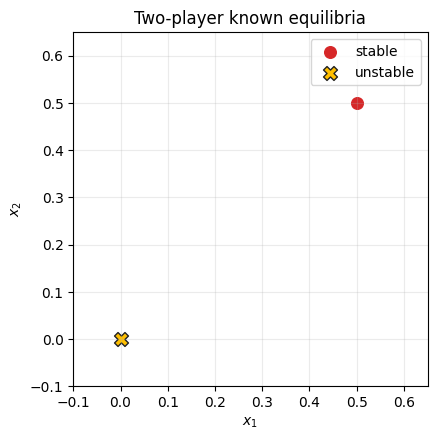

In [18]:
# BLOCK 2B — Editable two-player arguments and equilibrium graph.
N_2D = 1000 # @param {type:"integer"}
WIDTH_2D = 32 # @param {type:"integer"}
DEPTH_2D = 2 # @param {type:"integer"}
TANGENT_SIZE_2D = 64 # @param {type:"integer"}
SVD_RTOL_2D = 1e-5 # @param {type:"number"}
REFIT_INTERVAL_2D = 50 # @param {type:"integer"}
REFIT_STEPS_2D = 2000 # @param {type:"integer"}
REFIT_LR_2D = 1e-3 # @param {type:"number"}
REFIT_BATCH_2D = 2048 # @param {type:"integer"}
REFIT_SAMPLES_2D = 10000 # @param {type:"integer"}
REFIT_TEST_SAMPLES_2D = 4000 # @param {type:"integer"}
STEP_SIZE_2D = 0.02 # @param {type:"number"}
STEPS_2D = 50 # @param {type:"integer"}
NOISE_STD_2D = 0.1 # @param {type:"number"}
SEED_2D = 0 # @param {type:"integer"}
INITIAL_2D = 'uniform' # @param ["uniform", "gaussian"]
RUN_EM_2D = True # @param {type:"boolean"}
DEVICE_2D = 'auto' # @param ["auto", "cpu", "cuda"]

EQUILIBRIA_2D = np.array([[0.0, 0.0], [0.5, 0.5]])
STABLE_2D = np.array([False, True])
OUT_2D = OUTPUT_ROOT / 'two_player'
ARGS_2D = build_experiment_args(
    game='cournot', dim=2, particles=N_2D, width=WIDTH_2D, depth=DEPTH_2D,
    basis_size=TANGENT_SIZE_2D, svd_rtol=SVD_RTOL_2D,
    steps=STEPS_2D, step_size=STEP_SIZE_2D, noise_std=NOISE_STD_2D, seed=SEED_2D,
    initial_distribution=INITIAL_2D, run_sde_baseline=RUN_EM_2D,
    device=DEVICE_2D, output_dir=OUT_2D,
    refit_interval=REFIT_INTERVAL_2D, refit_optimizer_steps=REFIT_STEPS_2D,
    refit_learning_rate=REFIT_LR_2D, refit_batch_size=REFIT_BATCH_2D,
    refit_samples=REFIT_SAMPLES_2D, refit_test_samples=REFIT_TEST_SAMPLES_2D,
)
print_configuration('TWO-PLAYER GAME', ARGS_2D, EQUILIBRIA_2D, STABLE_2D)
plot_equilibria(EQUILIBRIA_2D, STABLE_2D, 'Two-player known equilibria')


In [7]:
# BLOCK 2C — Run the two-player DTB and optional matched Euler–Maruyama baseline.
RUN_2D = False # @param {type:"boolean"}
if RUN_2D:
    run_experiment(ARGS_2D)
else:
    print('Two-player computation skipped. Set RUN_2D=True when ready.')


Two-player computation skipped. Set RUN_2D=True when ready.


In [8]:
# BLOCK 2D — Two-player snapshots, stable/unstable markers, diagnostics, and metrics.
if (OUT_2D / 'history.npz').exists():
    display_saved_artifacts(OUT_2D)
    plot_saved_diagnostics(OUT_2D, 'Two-player Neural–DTB diagnostics')
    metrics_2d, comparison_2d = summarize_saved_run(OUT_2D, EQUILIBRIA_2D, STABLE_2D)
    display(metrics_2d)
    if comparison_2d is not None:
        display(Markdown('### Final Neural–DTB versus Euler–Maruyama discrepancies'))
        display(comparison_2d)
else:
    print('No two-player output yet. Run Block 2C first.')


No two-player output yet. Run Block 2C first.


# Experiment 2 — Three-player non-potential Cournot game

## Block 3A — Game, dimension, equilibria, network, tangent size, and SVD setup

**Game dimension:** $d=3$. Let $r_i=\sum_{j\ne i}x_j$. The equilibrium-consistent drift is

$$b_i(x)=-2x_i+4r_i-4r_i^2.$$

**Known equilibria:** $(0,0,0)$ is unstable. The four stable equilibria are $(3/8,3/8,3/8)$ and the three permutations of $(1/2,1/2,0)$.

**Default initial NN:** depth-4 `tanh` MLP, $3	o32	o32	o32	o32	o3$.

**Required controlled default:** 2,000 samples, $m=128$, relative SVD tolerance $10^{-3}$, and a matched Euler–Maruyama baseline.

=== THREE-PLAYER GAME CONTROLLED SETUP ===
Game / player dimension: cournot3 / d=3
Particles: N=2000; initial law=uniform on [0,1]^3
Physical grid: K=200, h=0.005, T=1
Noise amplitude: sigma=0.1; diffusion diagonal D_ii=0.01
Initial tangent NN: MLP 3 -> 32 -> 32 -> 32 -> 32 -> 3
Hidden depth=4; width=32; activation=tanh
Trainable tangent parameters M=3395
Selected tangent-bundle size m=128
Relative SVD tolerance=0.001
Source-matching reset: L=50 steps (0 disables); Adam steps=2000
Reset fit: lr=0.001; batch=2048; train samples=10000; fresh-test samples=4000
Euler–Maruyama baseline enabled=True
Device=auto; seed=0; output=outputs/controlled_colab/three_player_n2000_depth4
Known equilibria:
  E1: [0. 0. 0.] [unstable]
  E2: [0.375 0.375 0.375] [stable]
  E3: [0.5 0.5 0. ] [stable]
  E4: [0.5 0.  0.5] [stable]
  E5: [0.  0.5 0.5] [stable]


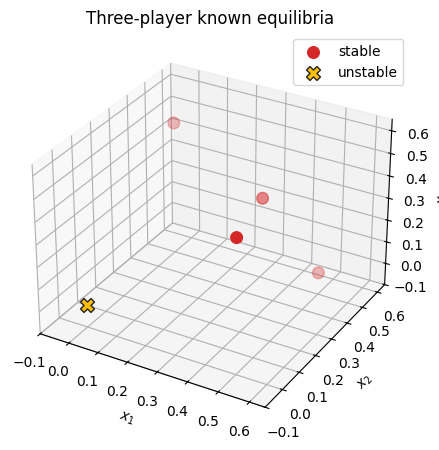

In [9]:
# BLOCK 3B — Editable three-player arguments and equilibrium graph.
N_3D = 2000 # @param {type:"integer"}
WIDTH_3D = 32 # @param {type:"integer"}
DEPTH_3D = 4 # @param {type:"integer"}
TANGENT_SIZE_3D = 128 # @param {type:"integer"}
SVD_RTOL_3D = 1e-3 # @param {type:"number"}
REFIT_INTERVAL_3D = 50 # @param {type:"integer"}
REFIT_STEPS_3D = 2000 # @param {type:"integer"}
REFIT_LR_3D = 1e-3 # @param {type:"number"}
REFIT_BATCH_3D = 2048 # @param {type:"integer"}
REFIT_SAMPLES_3D = 10000 # @param {type:"integer"}
REFIT_TEST_SAMPLES_3D = 4000 # @param {type:"integer"}
STEP_SIZE_3D = 0.005 # @param {type:"number"}
STEPS_3D = 200 # @param {type:"integer"}
NOISE_STD_3D = 0.1 # @param {type:"number"}
SEED_3D = 0 # @param {type:"integer"}
RUN_EM_3D = True # @param {type:"boolean"}
DEVICE_3D = 'auto' # @param ["auto", "cpu", "cuda"]

EQUILIBRIA_3D = np.array([
    [0.0, 0.0, 0.0],
    [3/8, 3/8, 3/8],
    [0.5, 0.5, 0.0],
    [0.5, 0.0, 0.5],
    [0.0, 0.5, 0.5],
])
STABLE_3D = np.array([False, True, True, True, True])
OUT_3D = OUTPUT_ROOT / 'three_player_n2000_depth4'
ARGS_3D = build_experiment_args(
    game='cournot3', dim=3, particles=N_3D, width=WIDTH_3D, depth=DEPTH_3D,
    basis_size=TANGENT_SIZE_3D, svd_rtol=SVD_RTOL_3D,
    steps=STEPS_3D, step_size=STEP_SIZE_3D, noise_std=NOISE_STD_3D, seed=SEED_3D,
    run_sde_baseline=RUN_EM_3D, device=DEVICE_3D, output_dir=OUT_3D,
    refit_interval=REFIT_INTERVAL_3D, refit_optimizer_steps=REFIT_STEPS_3D,
    refit_learning_rate=REFIT_LR_3D, refit_batch_size=REFIT_BATCH_3D,
    refit_samples=REFIT_SAMPLES_3D, refit_test_samples=REFIT_TEST_SAMPLES_3D,
)
print_configuration('THREE-PLAYER GAME', ARGS_3D, EQUILIBRIA_3D, STABLE_3D)
plot_equilibria(EQUILIBRIA_3D, STABLE_3D, 'Three-player known equilibria')


## Block 3C — Controlled Euler–Maruyama comparison

When `RUN_EM_3D=True`, the runner starts Euler–Maruyama from exactly the same initial particle cloud and uses the same drift, $h$, $\sigma$, and snapshot times as DTB. The random noise uses a separate recorded seed.

The results block reports final mean-vector error, covariance error, and sliced Wasserstein distance in addition to equilibrium-distance metrics.

In [17]:
# BLOCK 3D — Run the requested 2,000-sample, depth-4 three-player experiment.
RUN_3D = True # @param {type:"boolean"}
if RUN_3D:
    run_experiment(ARGS_3D)
else:
    print('Three-player computation skipped. Set RUN_3D=True when ready.')


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


DTB  10% | step 20/200 | t=0.1000 | projection: relative=9.309e-02, particle-RMSE=1.531e-01 | rank=39/128 | refits=0 | elapsed=35s | ETA=5m 13s
DTB  20% | step 40/200 | t=0.2000 | projection: relative=2.047e-01, particle-RMSE=1.906e-01 | rank=35/128 | refits=0 | elapsed=1m 02s | ETA=4m 07s
  refit #1 (periodic) RMSE 4.491e-01 -> 1.366e-02 on fresh reference samples
DTB  30% | step 60/200 | t=0.3000 | projection: relative=1.144e-01, particle-RMSE=7.268e-02 | rank=49/128 | refits=1 | elapsed=1m 33s | ETA=3m 38s
DTB  40% | step 80/200 | t=0.4000 | projection: relative=1.151e-01, particle-RMSE=6.677e-02 | rank=47/128 | refits=1 | elapsed=2m 00s | ETA=2m 59s
DTB  50% | step 100/200 | t=0.5000 | projection: relative=9.820e-02, particle-RMSE=5.408e-02 | rank=45/128 | refits=2 | elapsed=2m 30s | ETA=2m 30s
  refit #2 (periodic) RMSE 4.742e-01 -> 1.383e-02 on fresh reference samples
DTB  60% | step 120/200 | t=0.6000 | projection: relative=1.084e-01, particle-RMSE=5.184e-02 | rank=46/128 | refi

In [11]:
# BLOCK 3E — Three-player snapshots, stable/unstable markers, diagnostics, and EM metrics.
if (OUT_3D / 'history.npz').exists():
    display_saved_artifacts(OUT_3D)
    plot_saved_diagnostics(OUT_3D, 'Three-player Neural–DTB diagnostics')
    metrics_3d, comparison_3d = summarize_saved_run(OUT_3D, EQUILIBRIA_3D, STABLE_3D)
    display(metrics_3d)
    if comparison_3d is not None:
        display(Markdown('### Final Neural–DTB versus Euler–Maruyama discrepancies'))
        display(comparison_3d)
else:
    print('No three-player output yet. Run Block 3D first.')


No three-player output yet. Run Block 3D first.


# Experiment 3 — Five-player constrained non-potential Cournot game

## Block 4A — Game, dimension, equilibria, network, tangent size, and SVD setup

**Game dimension:** $d=5$. For $r_i=\sum_{j\ne i}x_j$, nonnegative quantities use

$$\operatorname{BR}_i(x)=\max\{2r_i(1-r_i),0\},\qquad b_i(x)=2[\operatorname{BR}_i(x)-x_i].$$

**Known equilibria:** the origin, $(7/32)^5$, and the five coordinate permutations of $(0,5/18,5/18,5/18,5/18)$. The thesis reports all seven as unstable.

**Default initial NN:** depth-4 `tanh` MLP, $5	o32	o32	o32	o32	o5$.

**Required controlled default:** 2,000 samples, $m=128$, and relative SVD tolerance $10^{-3}$. Because all known equilibria are unstable, distance to them is a diagnostic, not an expected convergence target.

=== FIVE-PLAYER GAME CONTROLLED SETUP ===
Game / player dimension: cournot5 / d=5
Particles: N=2000; initial law=uniform on [0,1]^5
Physical grid: K=200, h=0.005, T=1
Noise amplitude: sigma=0.1; diffusion diagonal D_ii=0.01
Initial tangent NN: MLP 5 -> 32 -> 32 -> 32 -> 32 -> 5
Hidden depth=4; width=32; activation=tanh
Trainable tangent parameters M=3525
Selected tangent-bundle size m=128
Relative SVD tolerance=0.001
Source-matching reset: L=50 steps (0 disables); Adam steps=2000
Reset fit: lr=0.001; batch=2048; train samples=10000; fresh-test samples=4000
Euler–Maruyama baseline enabled=True
Device=auto; seed=0; output=outputs/controlled_colab/five_player_n2000_depth4
Known equilibria:
  E1: [0. 0. 0. 0. 0.] [unstable]
  E2: [0.21875 0.21875 0.21875 0.21875 0.21875] [unstable]
  E3: [0.      0.27778 0.27778 0.27778 0.27778] [unstable]
  E4: [0.27778 0.      0.27778 0.27778 0.27778] [unstable]
  E5: [0.27778 0.27778 0.      0.27778 0.27778] [unstable]
  E6: [0.27778 0.27778 0.27778 0. 

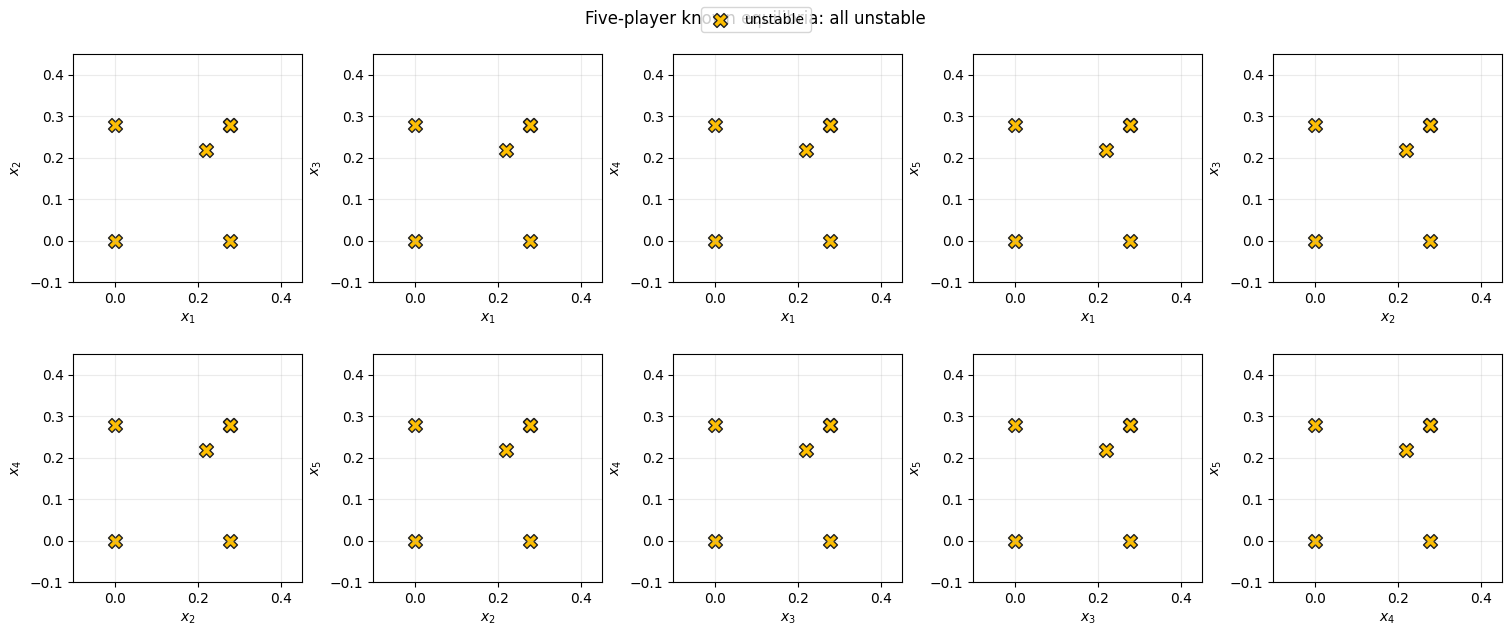

In [12]:
# BLOCK 4B — Editable five-player arguments and all ten pairwise equilibrium graphs.
N_5D = 2000 # @param {type:"integer"}
WIDTH_5D = 32 # @param {type:"integer"}
DEPTH_5D = 4 # @param {type:"integer"}
TANGENT_SIZE_5D = 128 # @param {type:"integer"}
SVD_RTOL_5D = 1e-3 # @param {type:"number"}
REFIT_INTERVAL_5D = 50 # @param {type:"integer"}
REFIT_STEPS_5D = 2000 # @param {type:"integer"}
REFIT_LR_5D = 1e-3 # @param {type:"number"}
REFIT_BATCH_5D = 2048 # @param {type:"integer"}
REFIT_SAMPLES_5D = 10000 # @param {type:"integer"}
REFIT_TEST_SAMPLES_5D = 4000 # @param {type:"integer"}
STEP_SIZE_5D = 0.005 # @param {type:"number"}
STEPS_5D = 200 # @param {type:"integer"}
NOISE_STD_5D = 0.1 # @param {type:"number"}
SEED_5D = 0 # @param {type:"integer"}
RUN_EM_5D = True # @param {type:"boolean"}
DEVICE_5D = 'auto' # @param ["auto", "cpu", "cuda"]

equilibria_5d = [np.zeros(5), np.full(5, 7/32)]
for zero_index in range(5):
    point = np.full(5, 5/18)
    point[zero_index] = 0.0
    equilibria_5d.append(point)
EQUILIBRIA_5D = np.asarray(equilibria_5d)
STABLE_5D = np.zeros(len(EQUILIBRIA_5D), dtype=bool)
OUT_5D = OUTPUT_ROOT / 'five_player_n2000_depth4'
ARGS_5D = build_experiment_args(
    game='cournot5', dim=5, particles=N_5D, width=WIDTH_5D, depth=DEPTH_5D,
    basis_size=TANGENT_SIZE_5D, svd_rtol=SVD_RTOL_5D,
    steps=STEPS_5D, step_size=STEP_SIZE_5D, noise_std=NOISE_STD_5D, seed=SEED_5D,
    run_sde_baseline=RUN_EM_5D, device=DEVICE_5D, output_dir=OUT_5D,
    refit_interval=REFIT_INTERVAL_5D, refit_optimizer_steps=REFIT_STEPS_5D,
    refit_learning_rate=REFIT_LR_5D, refit_batch_size=REFIT_BATCH_5D,
    refit_samples=REFIT_SAMPLES_5D, refit_test_samples=REFIT_TEST_SAMPLES_5D,
)
print_configuration('FIVE-PLAYER GAME', ARGS_5D, EQUILIBRIA_5D, STABLE_5D)
plot_equilibria(EQUILIBRIA_5D, STABLE_5D, 'Five-player known equilibria: all unstable')


In [13]:
# BLOCK 4C — Run the requested 2,000-sample, depth-4 five-player experiment.
RUN_5D = False # @param {type:"boolean"}
if RUN_5D:
    run_experiment(ARGS_5D)
else:
    print('Five-player computation skipped. Set RUN_5D=True when ready.')


Five-player computation skipped. Set RUN_5D=True when ready.


In [14]:
# BLOCK 4D — Five-player projected snapshots, ten final pairwise plots, diagnostics, and metrics.
if (OUT_5D / 'history.npz').exists():
    display_saved_artifacts(OUT_5D, show_pairwise=True)
    plot_saved_diagnostics(OUT_5D, 'Five-player Neural–DTB diagnostics')
    metrics_5d, comparison_5d = summarize_saved_run(OUT_5D, EQUILIBRIA_5D, STABLE_5D)
    display(metrics_5d)
    display(Markdown('Distances use all seven known unstable equilibria and are not convergence scores.'))
    if comparison_5d is not None:
        display(Markdown('### Final Neural–DTB versus Euler–Maruyama discrepancies'))
        display(comparison_5d)
else:
    print('No five-player output yet. Run Block 4C first.')


No five-player output yet. Run Block 4C first.


## Block 5 — Optional compact cross-experiment table

Run this after any subset of the experiments. It reads only output folders that already exist. Because the games have different dimensions and stability structures, compare residual and rank trends cautiously rather than treating the rows as a universal ranking.

In [15]:
# BLOCK 5A — Collect the DTB rows from all completed experiments.
completed = []
for label, folder, equilibria, stable in [
    ('2D', OUT_2D, EQUILIBRIA_2D, STABLE_2D),
    ('3D', OUT_3D, EQUILIBRIA_3D, STABLE_3D),
    ('5D', OUT_5D, EQUILIBRIA_5D, STABLE_5D),
]:
    if (folder / 'history.npz').exists():
        table, _ = summarize_saved_run(folder, equilibria, stable)
        row = table.iloc[0].to_dict()
        row['experiment'] = label
        completed.append(row)
if completed:
    display(pd.DataFrame(completed).set_index('experiment'))
else:
    print('No completed experiment folders were found.')


No completed experiment folders were found.


## Block 6 — Optional persistence to Google Drive

Colab storage is temporary. Enable the switch below after your runs to copy the complete controlled output folder—including `history.npz`, configuration JSON, DTB figures, Euler–Maruyama figures, and diagnostics—to Google Drive.

In [16]:
# BLOCK 6A — Save outputs only when explicitly enabled.
SAVE_TO_DRIVE = False # @param {type:"boolean"}
DRIVE_DESTINATION = '/content/drive/MyDrive/dtb_controlled_experiments' # @param {type:"string"}
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    destination = Path(DRIVE_DESTINATION)
    if destination.exists():
        shutil.rmtree(destination)
    shutil.copytree(OUTPUT_ROOT, destination)
    print('Saved controlled experiments to:', destination)
else:
    print('Drive copy skipped. Set SAVE_TO_DRIVE=True after completing the desired runs.')


Drive copy skipped. Set SAVE_TO_DRIVE=True after completing the desired runs.


## Reading and troubleshooting the results

- **Red circles** are stable equilibria; **gold X markers** are unstable equilibria. All seven marked 5D equilibria are unstable.
- `projection_residuals` measure how well the selected tangent span fits the target velocity. Low residual is necessary but not sufficient for distributional accuracy.
- `retained_ranks` show how many singular directions survive the relative SVD cutoff. A suddenly collapsing rank may indicate a poor tangent dictionary or excessive cutoff.
- Compare DTB with Euler–Maruyama using the point-cloud panels, means, covariances, sliced Wasserstein distance, and equilibrium-distance statistics together.
- If GPU memory is exhausted, reduce `N_*`, `TANGENT_SIZE_*`, `WIDTH_*`, `jacobian_chunk`, or `derivative_chunk`. Restart the runtime between the 3D and 5D jobs if necessary.
- If a run becomes unstable, reduce `STEP_SIZE_*` while increasing `STEPS_*` so that `STEP_SIZE_* × STEPS_* = 1`.
- Every run writes its exact arguments to `config.json`; keep that file with every figure used in a report.